In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# CONEXÃO COM O BANCO DE DADOS
# Utilizado IA para auxiliar na conexão com o banco, entregando a sintaxe correta para criação da engine.
user = "looqbox-challenge"
password = "looq-challenge"
host = "35.199.115.174"
port = "3306"
db = "looqbox-challenge"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}")

In [9]:
# 1ª QUESTÃO: Criar uma função dinamica que permita filtros ou não na tabela data_product_sales:

def retrieve_data(product_code = None, store_code = None, date = None):
    query = "SELECT * FROM data_product_sales WHERE 1=1"

    if product_code is not None:
        query += f" AND PRODUCT_CODE = {product_code}"
        
    if store_code is not None:
        query += f" AND STORE_CODE = {store_code}"
        
    if date is not None and len(date) == 2:
        query += f" AND DATE BETWEEN '{date[0]}' AND '{date[1]}'"
    
    df = pd.read_sql(query, con=engine)
    return df

my_data = retrieve_data(product_code=None, store_code=None, date=None)
my_data

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.50,65.0
1,1,18,2019-01-02,1297.10,119.0
2,1,18,2019-01-03,1144.50,105.0
3,1,18,2019-01-04,1090.00,100.0
4,1,18,2019-01-05,893.80,82.0
...,...,...,...,...,...
2173128,9,241404,2019-12-27,7671.75,193.0
2173129,9,241404,2019-12-28,6201.00,156.0
2173130,9,241404,2019-12-29,4889.25,123.0
2173131,9,241404,2019-12-30,4730.25,119.0


In [10]:
#2ª QUESTÃO: Utilizar queries preestabelecidas para dar merge e retornar df com Loja, Categoria e Ticket Médio:

query1 = """
SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad
"""
query2 = """
SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
"""
df_store_cad = pd.read_sql(query1, con=engine)
df_store_sales = pd.read_sql(query2, con=engine)

# Join nas tabelas, PK = STORE_CODE

df_merged = pd.merge(df_store_sales, df_store_cad, on ='STORE_CODE', how = 'inner')
df_merged['DATE'] = pd.to_datetime(df_merged['DATE'])
initial_date = "2019-10-01"
end_date = "2019-12-31"

df_filtered = df_merged[(df_merged['DATE'] >= initial_date) & (df_merged['DATE'] <= end_date)]

# Realizar group by e agregação para formatar o resultado final

df_grouped = df_filtered.groupby(['STORE_NAME', 'BUSINESS_NAME']).agg(
    TOTAL_VAL = ('SALES_VALUE', 'sum'),
    TOTAL_QTY = ('SALES_QTY', 'sum')
).reset_index()

df_grouped['TM'] = (df_grouped['TOTAL_VAL'] / df_grouped['TOTAL_QTY']).round(2)

# Renomear colunas para formatação

df_final = df_grouped[['STORE_NAME', 'BUSINESS_NAME', 'TM']].rename(
    columns = {
        'STORE_NAME': "Loja",
        'BUSINESS_NAME': "Categoria"
    }
)
df_final


,Loja,Categoria,TM
0,Bahia,Atacado,15.39
1,Bangkok,Posto,13.67
2,Belem,Proximidade,15.37
3,Berlin,Proximidade,15.39
4,Buenos Aires,Atacado,15.39
5,Chicago,Varejo,15.53
6,Dubai,Atacado,15.39
7,Hong Kong,Farma,26.35
8,London,Farma,28.99
9,Madri,Farma,29.03


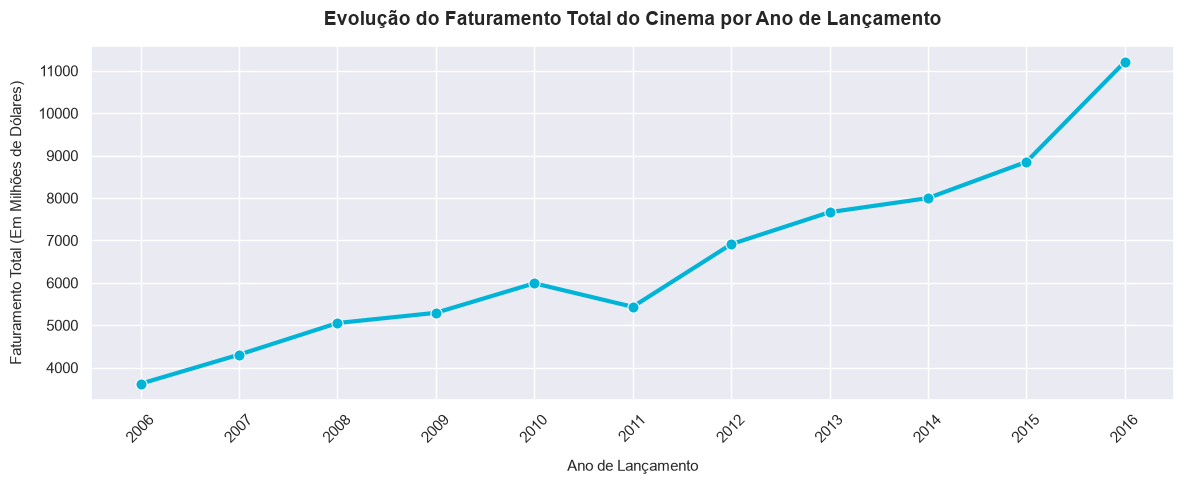

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

query = "SELECT * FROM IMDB_movies"
df_imdb = pd.read_sql(query, con=engine)

# Resolvi plotar o faturamento total por ser um gráfico simples capaz de verificar a evolução temporal do faturamento dos cinemas,
# servindo como visão geral do mercado, além de servir como aleta para possíveis explorações do que houve por exemplo na queda em 2011.
# Foi utilizado IA para a sintaxe do sns/plt, facilitando o processo de criação do gráfico.

df_fat_ano = df_imdb.groupby('Year')['RevenueMillions'].sum().reset_index()

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_fat_ano,
    x='Year',
    y='RevenueMillions',
    marker='o',
    markersize=8,
    color='#00B4D8',
    linewidth=3
)

plt.title("Evolução do Faturamento Total do Cinema por Ano de Lançamento", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Ano de Lançamento", fontsize=11, labelpad=10)
plt.ylabel("Faturamento Total (Em Milhões de Dólares)", fontsize=11, labelpad=10)

anos_unicos = df_fat_ano['Year'].unique()
plt.xticks(anos_unicos, rotation=45)
plt.tight_layout()
plt.show()